<a href="https://colab.research.google.com/github/svyatoslavna/nlp_hw/blob/main/w2v_hw_advanced.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Разбор архитектуры Word2Vec: CBOW (Continuous Bag-of-Words) и Skip-Gram с Negative Sampling

- Загрузка и предобработка корпуса новостей
- Обучение моделей
- Визуализация
- Анализ эмбеддингов

---
# Домашнее задание (Word2Vec Advanced)

**Задание состоит из двух частей:**

1.  **Практическая часть: Обучение и анализ.**
    *   Обучите модели CBOW и Skip-Gram с Negative Sampling на предоставленном корпусе новостей, используя код из ноутбука.
    *   Для одной из моделей (на ваш выбор) проведите визуализацию эмбеддингов (как в п. 7.1) для 15-20 слов, относящихся к разным тематикам (например, политика, спорт, медицина, культура).
    *   **Проанализируйте** получившийся график: образуют ли слова из одной темы кластеры? Есть ли слова, которые, на ваш взгляд, находятся не в своем кластере? Почему это могло произойти?

2.  **Аналитическая часть: Эксперимент с гиперпараметрами.**
    *   Выберите одну из моделей (например, Skip-Gram) и один набор тестовых слов (например, `['коронавирус', 'инфекция', 'болезнь', 'вакцина']`).
    *   Проведите небольшое исследование, как изменение следующих гиперпараметров влияет на качество получаемых эмбеддингов (используйте косинусное сходство или аналогии как метрику):
        *   **Размер окна (window size):** Попробуйте значения 1, 3, 5.
        *   **Размерность эмбеддинга (embedding size):** Попробуйте значения 50, 100, 200.
    *   **Опишите** свои наблюдения. Какой размер окна лучше подходит для поиска тематически близких слов, а какой — для синтаксически близких? Влияет ли размерность на скорость обучения и на качество?

**Формат сдачи:**
Оформите отчет (в формате `.ipynb` или `.pdf`), который включает:
*   Краткое описание проделанной работы.
*   Графики из п.1 и ваш анализ к ним.
*   Таблицу или графики, иллюстрирующие влияние гиперпараметров из п.2, и ваши выводы.

# **Практическая часть: Обучение и анализ.**

## 1. Загрузка библиотек

In [2]:
# для цветного вывода в консоль (опционально)
# для морфологического анализа (PoS-тэггинг)
!pip install colorama natasha -q

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.4/34.4 MB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.5/55.5 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 96.6 MB/s eta 0:00:00


In [3]:
from colorama import Fore, Style
import json
import random

from natasha import NewsMorphTagger, NewsEmbedding, Doc, Segmenter

import re
from collections import defaultdict
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import SGD, Adam
from torch.utils.data import DataLoader, Dataset
import copy

from sklearn.decomposition import TruncatedSVD, PCA
import matplotlib.pyplot as plt

# Для корректного отображения графиков в Colab
%matplotlib inline

# Определяем устройство один раз глобально
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"{Fore.GREEN}Используется устройство: {device}{Style.RESET_ALL}")

Используется устройство: cuda


## 2. Загрузка и подготовка корпуса

Мы будем работать с корпусом новостей [Московского комсомольца](https://github.com/vifirsanova/W2V/blob/main/corpus.json). Он уже собран и подготовлен.

In [7]:
# загружаем корпус
!wget -q --show-progress https://raw.githubusercontent.com/vifirsanova/W2V/main/corpus.json

with open('corpus.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

print(f"{Fore.GREEN}Корпус загружен. Пример записи:{Style.RESET_ALL}")
data['data'][0]

corpus.json         100%[===================>]  87.84M   310MB/s    in 0.3s    
Корпус загружен. Пример записи:


{'link': 'https://www.mk.ru/social/2020/03/31/minobrnauki-pereneslo-vstupitelnye-ekzameny-v-vuzy-izza-koronavirusa.html',
 'title': 'Минобрнауки решило перенести вступительные экзамены в вузы из-за коронавируса',
 'date': '31.03.2020',
 'time': '09:11',
 'rubric': 'Общество',
 'text': '\nВ Минобрнауки РФ приняли решение перенести даты вступительных экзаменов в вузы из-за коронавируса, заявил глава ведомства Валерий Фальков в интервью «Россия 24».\nОн отметил, что в этом году число бюджетных мест было увеличено на 34 тысячи. Сейчас начался экономический спад, но менять стратегию в министерстве не намерены.\nРешение об увеличении бюджетных мест в вузах связано с ростом числа выпускников школ. Будет увеличено число мест на педагогическом и медицинском направлениях. Большой запрос на бюджетные места у регионов, подчеркнул Фальков.\nРанее власти перенесли даты ЕГЭ и ОГЭ.\nЧитайте также:\xa0Скворцова похвалила российский препарат от коронавируса\n\xa0\n\n'}

In [8]:
# извлекаем тексты и перемешиваем
full_dataset = [item['text'] for item in data['data']]
random.shuffle(full_dataset)

# разделяем на train/val -> sklearn test_train_split
split = int(0.8 * len(full_dataset))
train_texts = full_dataset[:split]
val_texts = full_dataset[split:]

# Урезаем размер выборки для быстрого обучения
TRAIN_SAMPLE_SIZE = 5000  # вместо 36736
VAL_SAMPLE_SIZE = 1000    # вместо 9184

train_texts = train_texts[:TRAIN_SAMPLE_SIZE]
val_texts = val_texts[:VAL_SAMPLE_SIZE]

print(f"{Fore.GREEN}Урезанная обучающая выборка: {len(train_texts)} документов{Style.RESET_ALL}")
print(f"{Fore.GREEN}Урезанная проверочная выборка: {len(val_texts)} документов{Style.RESET_ALL}")
print(f"{Fore.GREEN}\nПример текста:{Style.RESET_ALL}\n{train_texts[0][:500]}...")

Урезанная обучающая выборка: 5000 документов
Урезанная проверочная выборка: 1000 документов

Пример текста:

В Бабушкинском суде Москвы началось заседание по делу в отношении оппозиционера Алексея Навального о клевете. В зал пустили журналистов. Политик молча стоит в "аквариуме", скрестив руки на груди.
Поначалу казалось, что адвокаты блогера не явились на заседание. Тем не менее, сам Навальный исключил, что его защитники не придут. В итоге адвокаты действительно появились в зале с опозданием.
Также в зале появилась прокурор Екатерина Фролова. Именно она представляла обвинение на заседании Симоновског...


## 3. Морфологический анализ (PoS-tagging)

Хотя для Word2Vec разметка не обязательна, она поможет нам позже при анализе коллокатов. Мы воспользуемся библиотекой `natasha`.

In [9]:
# создаем объекты Doc
train_docs = [Doc(text) for text in train_texts[:100]] # Для демо возьмем часть
val_docs = [Doc(text) for text in val_texts[:20]]

# сегментируем на токены и предложения
segmenter = Segmenter()
for doc in train_docs + val_docs:
    doc.segment(segmenter)
print(doc)
# тэггируем части речи
morph_tagger = NewsMorphTagger(NewsEmbedding())
for doc in train_docs + val_docs:
    doc.tag_morph(morph_tagger)

print(f"{Fore.GREEN}Пример размеченного токена:{Style.RESET_ALL}")
tok = val_docs[0].tokens[0]
print(f"Слово: {tok.text}, PoS: {tok.pos}, Морфология: {tok.feats}")

Doc(text='\nНа президентских выборах в Соединенных Штатах, ..., tokens=[...], sents=[...])
Пример размеченного токена:
Слово: Сестра, PoS: NOUN, Морфология: {'Animacy': 'Anim', 'Case': 'Nom', 'Gender': 'Fem', 'Number': 'Sing'}


In [10]:
doc.text

'\nНа президентских выборах в Соединенных Штатах, прошедших 3 ноября, лидирует кандидат от демократов Джо Байден. По подсчетам, политик набрал уже 264 голоса избирателей при необходимых 270. У его конкурента – действующего президента США Дональда Трампа – 214 голосов.\nНеясным остается итоговый расклад в нескольких американских штатах: Неваде, Джорджии, Северной Каролине и Пенсильвании. В трех последних, по предварительным данным, победу должен одержать Трамп. При этом исход выборов определит подсчет голосов в Неваде, которая может обеспечить Байдену шесть необходимых голосов.\nВ настоящее время обработано 75% бюллетеней. Согласно предварительным результатам, Байден опережает Трампа н 0,6%.\nТем временем, о победе уже заявляли как в штабе действующего американского лидера, так и в Штабе демократов. Аналитики считают, что Джо Байден обошел конкурента в ключевых штатах Висконсин и Мичиган, обеспечив себе лидерство. Кроме того, на финальных этапах Байдену помогло и голосование по почте, к

In [11]:
doc.tokens

[DocToken(start=1, stop=3, text='На', pos='ADP'),
 DocToken(start=4, stop=17, text='президентских', pos='ADJ', feats=<Loc,Pos,Plur>),
 DocToken(start=18, stop=25, text='выборах', pos='NOUN', feats=<Inan,Loc,Masc,Plur>),
 DocToken(start=26, stop=27, text='в', pos='ADP'),
 DocToken(start=28, stop=39, text='Соединенных', pos='VERB', feats=<Perf,Loc,Plur,Past,Part,Pass>),
 DocToken(start=40, stop=46, text='Штатах', pos='PROPN', feats=<Inan,Loc,Masc,Plur>),
 DocToken(start=46, stop=47, text=',', pos='PUNCT'),
 DocToken(start=48, stop=57, text='прошедших', pos='VERB', feats=<Perf,Loc,Plur,Past,Part,Act>),
 DocToken(start=58, stop=59, text='3', pos='ADJ'),
 DocToken(start=60, stop=66, text='ноября', pos='NOUN', feats=<Inan,Gen,Masc,Sing>),
 DocToken(start=66, stop=67, text=',', pos='PUNCT'),
 DocToken(start=68, stop=76, text='лидирует', pos='VERB', feats=<Imp,Ind,Sing,3,Pres,Fin,Act>),
 DocToken(start=77, stop=85, text='кандидат', pos='NOUN', feats=<Anim,Nom,Masc,Sing>),
 DocToken(start=86, s

In [12]:
# сохраним разметку для будущих задач
def build_tag_dict(docs):
    tag_dict = {}
    for doc in docs:
        for tok in doc.tokens:
            if tok.text not in tag_dict:
                tag_dict[tok.text] = (tok.pos, tok.feats)
    return tag_dict

train_tag_dict = build_tag_dict(train_docs)
val_tag_dict = build_tag_dict(val_docs)

print(f"{Fore.GREEN}Размер словаря тегов: {len(train_tag_dict)}{Style.RESET_ALL}")

Размер словаря тегов: 4787


## 4. Токенизация и построение словаря

Теперь перейдем к основной предобработке для модели.

In [13]:
# Загружаем стоп-слова
!wget -q https://raw.githubusercontent.com/vifirsanova/W2V/main/swl.txt
with open('swl.txt', 'r', encoding='utf-8') as f:
    stop_words = set([line.strip() for line in f])

print(f"{Fore.GREEN}Загружено {len(stop_words)} стоп-слов. Пример: {list(stop_words)[:5]}{Style.RESET_ALL}")

# Токенизатор
def tokenize(text):
    """Разбивает текст на токены (слова и цифры), приводит к нижнему регистру."""
    return re.findall(r'[\w\d]+', text.lower())

train_tokenized = [tokenize(text) for text in train_texts]
val_tokenized = [tokenize(text) for text in val_texts]

print(f"{Fore.GREEN}Пример токенизации:{Style.RESET_ALL}")
print(' '.join(train_tokenized[0][:15]))

Загружено 925 стоп-слов. Пример: ['', 'P', 'точно', 'здравствуйте', 'отсюда']
Пример токенизации:
в бабушкинском суде москвы началось заседание по делу в отношении оппозиционера алексея навального о клевете


In [ ]:
defaultdict(int), dict()

(defaultdict(int, {}), {})

In [14]:
def build_vocab(tokenized_corpus, stop_words, pad_word='<PAD>'):
    """
    Строит словарь на основе токенизированного корпуса.
    Возвращает:
        word2id: соответствие слово -> индекс
        word_doc_freq: частотность слов в корпусе (количество документов, где слово встретилось)
    """
    doc_freq = defaultdict(int)
    for text in tokenized_corpus:
        # считаем по документо-частоте, а не по частоте вхождений
        #print(text)
        for word in set(text):
            if word not in stop_words:
                doc_freq[word] += 1
                #print(doc_freq)
            #else:
                #print(word, 'в списке стоп-слов!!')

    # удаляем редкие слова (встретились только в 1 документе)
    doc_freq = {w: cnt for w, cnt in doc_freq.items() if cnt > 1}

    # сортируем по убыванию частоты
    sorted_vocab = sorted(doc_freq.items(), key=lambda x: -x[1])
    words = [pad_word] + [w for w, _ in sorted_vocab]

    word2id = {w: i for i, w in enumerate(words)}
    word_doc_freq = np.array([0] + [cnt for _, cnt in sorted_vocab], dtype='float32')
    # нормируем, чтобы получить вероятность встретить слово в случайном документе
    word_doc_freq /= len(tokenized_corpus)

    return word2id, word_doc_freq

word2id, word_doc_freq = build_vocab(train_tokenized, stop_words)

vocab_size = len(word2id)
print(f"{Fore.GREEN}Размер словаря: {vocab_size}{Style.RESET_ALL}")
print(f"{Fore.GREEN}Первые 10 слов словаря:{Style.RESET_ALL}")
list(word2id.items())[:10]

Размер словаря: 25989
Первые 10 слов словаря:


[('<PAD>', 0),
 ('этом', 1),
 ('а', 2),
 ('россии', 3),
 ('ранее', 4),
 ('словам', 5),
 ('заявил', 6),
 ('будет', 7),
 ('коронавируса', 8),
 ('время', 9)]

### 4.1 Векторизация

Превращаем слова в их индексы в словаре.

In [15]:
def texts_to_ids(tokenized_corpus, word2id):
    """Заменяет слова на их индексы. Незнакомые слова игнорируются."""
    return [[word2id[token] for token in text if token in word2id] for text in tokenized_corpus]

train_ids = texts_to_ids(train_tokenized, word2id)
val_ids = texts_to_ids(val_tokenized, word2id)

print(f"{Fore.GREEN}Исходный текст:{Style.RESET_ALL} {train_tokenized[0][:5]}")
print(f"{Fore.GREEN}Числовые ID:{Style.RESET_ALL} {train_ids[0][:5]}")
print(f"{Fore.GREEN}Обратно по словарю:{Style.RESET_ALL} {[list(word2id.keys())[i] for i in train_ids[0][:5]]}")

Исходный текст: ['в', 'бабушкинском', 'суде', 'москвы', 'началось']
Числовые ID: [7531, 947, 157, 2104, 1207]
Обратно по словарю: ['бабушкинском', 'суде', 'москвы', 'началось', 'заседание']


## 5. Датасет и подготовка данных для CBOW

CBOW учится предсказывать центральное слово по его контексту. Нам нужно создать пары (контекст, цель).
**Контекст** — это набор слов вокруг цели. **Цель** — центральное слово.

In [24]:
# Гиперпараметры
CONTEXT_SIZE = 5  # Количество слов С КАЖДОЙ стороны от центрального. Всего контекст = 2*CONTEXT_SIZE
EMBEDDING_DIM = 300
EPOCHS_CBOW = 12

class CBOWDataset(Dataset):
    def __init__(self, data_ids, context_size):
        """
        data_ids: список текстов, где каждый текст - список ID токенов.
        context_size: сколько слов брать слева и справа.
        """
        self.pairs = []  # ( [id_контекстных_слов], id_целевого_слова )
        for text in data_ids:
            if len(text) < 2*context_size + 1:
                continue
            for i in range(context_size, len(text) - context_size):
                context = text[i-context_size:i] + text[i+1:i+context_size+1]
                target = text[i]
                self.pairs.append( (context, target) )

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        context, target = self.pairs[idx]
        return torch.tensor(context, dtype=torch.long), torch.tensor(target, dtype=torch.long)

# Создаем датасеты
cbow_train_dataset = CBOWDataset(train_ids, CONTEXT_SIZE)
cbow_val_dataset = CBOWDataset(val_ids, CONTEXT_SIZE)

print(f"{Fore.GREEN}Количество обучающих примеров для CBOW: {len(cbow_train_dataset)}{Style.RESET_ALL}")
print(f"{Fore.GREEN}Пример: контекст {cbow_train_dataset[0][0].tolist()} -> цель {cbow_train_dataset[0][1].item()}{Style.RESET_ALL}")

Количество обучающих примеров для CBOW: 438031
Пример: контекст [7531, 947, 157, 2104, 1207, 278, 2105, 650, 708, 2844] -> цель 451


### 5.1 Модель CBOW

In [25]:
class CBOW(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super(CBOW, self).__init__()
        self.embeddings = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        # Простой линейный слой для предсказания слова по среднему контекстному вектору
        self.linear = nn.Linear(embedding_dim, vocab_size)

    def forward(self, context_words):
        # context_words: (batch_size, 2*CONTEXT_SIZE)
        embeds = self.embeddings(context_words)  # (batch_size, 2*CONTEXT_SIZE, emb_dim)
        # Усредняем эмбеддинги контекстных слов
        averaged = torch.mean(embeds, dim=1)    # (batch_size, emb_dim)
        out = self.linear(averaged)             # (batch_size, vocab_size)
        log_probs = F.log_softmax(out, dim=1)
        return log_probs

    def get_word_vector(self, word_idx):
        """Возвращает вектор для заданного индекса слова."""
        return self.embeddings(torch.tensor([word_idx])).detach().cpu().numpy()[0]

In [ ]:
# Функция для обучения с поддержкой CUDA и ограничением батчей
def train_cbow(model, train_loader, val_loader, epochs, lr=0.001, device='cpu', max_batches=500):
    model.to(device)
    optimizer = Adam(model.parameters(), lr=lr)
    criterion = nn.NLLLoss()

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        batch_count = 0

        for i, (context, target) in enumerate(train_loader):
            if i >= max_batches:  # Ограничиваем количество батчей
                break

            context, target = context.to(device), target.to(device)

            optimizer.zero_grad()
            log_probs = model(context)
            loss = criterion(log_probs, target)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            batch_count += 1

        # Валидация (тоже ограничиваем)
        model.eval()
        val_loss = 0
        val_count = 0
        with torch.no_grad():
            for i, (context, target) in enumerate(val_loader):
                if i >= max_batches // 2:  # Меньше батчей для валидации
                    break
                context, target = context.to(device), target.to(device)
                log_probs = model(context)
                loss = criterion(log_probs, target)
                val_loss += loss.item()
                val_count += 1

        print(f"Epoch {epoch+1}, Train Loss: {total_loss/batch_count:.4f}, Val Loss: {val_loss/val_count:.4f}")

    return model

# Инициализация и обучение CBOW
cbow_model = CBOW(vocab_size, EMBEDDING_DIM)

# Оптимизация DataLoader
train_loader_cbow = DataLoader(
    cbow_train_dataset,
    batch_size=256,  # Увеличили batch_size
    shuffle=True,
    num_workers=2,  # Параллельная загрузка
    pin_memory=True  # Ускоряет передачу на GPU
)

val_loader_cbow = DataLoader(
    cbow_val_dataset,
    batch_size=256,
    num_workers=2,
    pin_memory=True
)

# Обучаем с ограничением батчей
cbow_model = train_cbow(cbow_model, train_loader_cbow, val_loader_cbow,
                        epochs=EPOCHS_CBOW, device=device, max_batches=500)

Epoch 1, Train Loss: 6.2839, Val Loss: 5.2340
Epoch 2, Train Loss: 5.1194, Val Loss: 4.9713
Epoch 3, Train Loss: 4.7707, Val Loss: 4.8452
Epoch 4, Train Loss: 4.5688, Val Loss: 4.7576
Epoch 5, Train Loss: 4.3294, Val Loss: 4.6928
Epoch 6, Train Loss: 4.1370, Val Loss: 4.6433
Epoch 7, Train Loss: 3.9158, Val Loss: 4.6040
Epoch 8, Train Loss: 3.7411, Val Loss: 4.5729
Epoch 9, Train Loss: 3.5540, Val Loss: 4.5510
Epoch 10, Train Loss: 3.3966, Val Loss: 4.5344
Epoch 11, Train Loss: 3.2174, Val Loss: 4.5233
Epoch 12, Train Loss: 3.0707, Val Loss: 4.5189


## 6. Skip-Gram with Negative Sampling (SGNS)

Skip-Gram предсказывает контекст по центральному слову.

Negative Sampling упрощает задачу, превращая ее в бинарную классификацию: учим модель отличать реальные пары (слово, контекст) от случайных (шумовых).

Для эффективности мы не будем генерировать все возможные пары (центр, контекст) заранее. Мы сделаем это *на лету* внутри датасета.

In [27]:
# Гиперпараметры для Skip-Gram
WINDOW_SIZE = 5          # Размер окна (с каждой стороны)
NEG_SAMPLES = 10          # Количество негативных примеров на один позитивный
EMB_DIM_SG = 300
EPOCHS_SG = 10

class SkipGramDataset(Dataset):
    def __init__(self, data_ids, window_size, neg_samples, vocab_size):
        self.data_ids = data_ids
        self.window_size = window_size
        self.neg_samples = neg_samples
        self.vocab_size = vocab_size
        self.pairs = []  # список (центр, контекст)
        for text in data_ids:
            text_len = len(text)
            for i, target in enumerate(text):
                # Определяем динамическое окно
                start = max(0, i - window_size)
                end = min(text_len, i + window_size + 1)
                for j in range(start, end):
                    if j == i: continue
                    self.pairs.append( (target, text[j]) )

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        center, pos_context = self.pairs[idx]
        # Генерируем негативные примеры
        neg_contexts = torch.randint(1, self.vocab_size, (self.neg_samples,))
        return (torch.tensor(center, dtype=torch.long),
                torch.tensor(pos_context, dtype=torch.long),
                neg_contexts)

# Уменьшаем датасет для Skip-Gram (берем только первые 1000 документов)
sg_dataset = SkipGramDataset(train_ids[:1000], WINDOW_SIZE, NEG_SAMPLES, vocab_size)
print(f"{Fore.GREEN}Урезанный датасет для Skip-Gram: {len(sg_dataset)} пар{Style.RESET_ALL}")

Урезанный датасет для Skip-Gram: 961910 пар


In [28]:
class SkipGramNegSampling(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super(SkipGramNegSampling, self).__init__()
        self.center_emb = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.context_emb = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        # Инициализация (Xavier)
        nn.init.xavier_uniform_(self.center_emb.weight)
        nn.init.xavier_uniform_(self.context_emb.weight)
        # Обнуляем паддинг
        self.center_emb.weight.data[0] = 0
        self.context_emb.weight.data[0] = 0

    def forward(self, center, pos_context, neg_contexts):
        """
        center: (batch_size,)
        pos_context: (batch_size,)
        neg_contexts: (batch_size, neg_samples)
        """
        center_vec = self.center_emb(center)  # (batch, emb_dim)
        pos_vec = self.context_emb(pos_context)  # (batch, emb_dim)
        neg_vecs = self.context_emb(neg_contexts)  # (batch, neg_samples, emb_dim)

        # Положительное сходство (чем больше, тем лучше)
        pos_score = torch.sum(center_vec * pos_vec, dim=1)  # (batch,)
        pos_loss = -F.logsigmoid(pos_score).mean()

        # Отрицательное сходство (чем меньше, тем лучше)
        neg_score = torch.bmm(neg_vecs, center_vec.unsqueeze(2)).squeeze()  # (batch, neg_samples)
        neg_loss = -F.logsigmoid(-neg_score).mean()

        return pos_loss + neg_loss

    def get_center_vector(self, word_idx):
        return self.center_emb(torch.tensor([word_idx])).detach().cpu().numpy()[0]

In [ ]:
def train_skipgram(model, dataset, epochs, batch_size=512, lr=0.01, device='cpu', max_batches=300):
    model.to(device)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True,
                       collate_fn=lambda x: list(zip(*x)), num_workers=2, pin_memory=True)
    optimizer = Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        batch_count = 0

        for i, batch in enumerate(loader):
            if i >= max_batches:
                break

            centers, pos_contexts, neg_contexts = batch
            centers = torch.stack(centers).to(device)
            pos_contexts = torch.stack(pos_contexts).to(device)
            neg_contexts = torch.stack(neg_contexts).to(device)

            optimizer.zero_grad()
            loss = model(centers, pos_contexts, neg_contexts)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            batch_count += 1

        print(f"Epoch {epoch+1}, Loss: {total_loss/batch_count:.4f}")

    return model

sg_model = SkipGramNegSampling(vocab_size, EMB_DIM_SG)
# Обучаем с ограничением батчей
sg_model = train_skipgram(sg_model, sg_dataset, epochs=EPOCHS_SG, batch_size=512,
                          device=device, max_batches=300)

Epoch 1, Loss: 0.8321
Epoch 2, Loss: 0.6333
Epoch 3, Loss: 0.5345
Epoch 4, Loss: 0.4592
Epoch 5, Loss: 0.4018
Epoch 6, Loss: 0.3572
Epoch 7, Loss: 0.3314
Epoch 8, Loss: 0.3086
Epoch 9, Loss: 0.2872
Epoch 10, Loss: 0.2725


## 7. Анализ эмбеддингов

Обучив модели, мы хотим понять, чему они научились. Создадим удобный класс для работы с эмбеддингами.

In [30]:
class WordEmbeddings:
    def __init__(self, embedding_matrix, word2id):
        """
        embedding_matrix: numpy array, shape (vocab_size, emb_dim)
        """
        self.embeddings = embedding_matrix
        # Нормируем для косинусного сходства
        self.norms = np.linalg.norm(self.embeddings, axis=1, keepdims=True)
        self.norms[self.norms == 0] = 1  # защита от деления на 0 для PAD
        self.normed_emb = self.embeddings / self.norms

        self.word2id = word2id
        self.id2word = {v: k for k, v in word2id.items()}

    def get_vector(self, word):
        if word not in self.word2id:
            raise KeyError(f"Слово '{word}' не найдено в словаре")
        return self.embeddings[self.word2id[word]]

    def most_similar(self, word, k=10):
        """Возвращает k самых близких слов по косинусной мере."""
        vec = self.get_vector(word)
        vec_normed = vec / (np.linalg.norm(vec) + 1e-8)
        scores = self.normed_emb @ vec_normed
        # Сортируем по убыванию и берем топ-k, исключая само слово
        best_ids = np.argsort(scores)[::-1]
        best_ids = [idx for idx in best_ids if idx != self.word2id[word]][:k]
        return [(self.id2word[idx], scores[idx]) for idx in best_ids]

    def analogy(self, word_a, word_b, word_c, k=5):
        """Решает пропорцию: word_a относится к word_b так же, как word_c относится к ?."""
        # vec_a - vec_b + vec_c
        vec = self.get_vector(word_a) - self.get_vector(word_b) + self.get_vector(word_c)
        vec_normed = vec / (np.linalg.norm(vec) + 1e-8)
        scores = self.normed_emb @ vec_normed
        best_ids = np.argsort(scores)[::-1]
        # Исключаем исходные слова из результата
        exclude_ids = {self.word2id.get(w, -1) for w in [word_a, word_b, word_c]}
        result = []
        for idx in best_ids:
            if idx not in exclude_ids:
                result.append((self.id2word[idx], scores[idx]))
            if len(result) == k:
                break
        return result

# Создаем объекты для наших моделей
cbow_emb = WordEmbeddings(cbow_model.embeddings.weight.detach().cpu().numpy(), word2id)
sg_emb = WordEmbeddings(sg_model.center_emb.weight.detach().cpu().numpy(), word2id)

In [31]:
# Примеры для CBOW
word = 'коронавирус'
print(f"{Fore.RED}Слова, похожие на '{word}' (CBOW):{Style.RESET_ALL}")
print(cbow_emb.most_similar(word, k=5))

print(f"\n{Fore.RED}Слова, похожие на '{word}' (Skip-Gram):{Style.RESET_ALL}")
print(sg_emb.most_similar(word, k=5))

# Аналогии
print(f"\n{Fore.RED}Аналогия 'король - мужчина + женщина' (Skip-Gram):{Style.RESET_ALL}")
print(sg_emb.analogy('король', 'мужчина', 'женщина', k=3))

Слова, похожие на 'коронавирус' (CBOW):
[('азербайджан', np.float32(0.23362365)), ('формироваться', np.float32(0.22820044)), ('классный', np.float32(0.22287679)), ('нежелания', np.float32(0.20614448)), ('hit', np.float32(0.20446198))]

Слова, похожие на 'коронавирус' (Skip-Gram):
[('находившихся', np.float32(0.21835682)), ('летальных', np.float32(0.21099545)), ('отравления', np.float32(0.20362368)), ('рынке', np.float32(0.202725)), ('серии', np.float32(0.19757488))]

Аналогия 'король - мужчина + женщина' (Skip-Gram):
[('сценарием', np.float32(0.21888918)), ('комиссия', np.float32(0.21514064)), ('международной', np.float32(0.20884934))]


### 7.1 Визуализация эмбеддингов

Спроецируем векторы интересующих нас слов на плоскость с помощью PCA.

Визуализация Skip-Gram эмбеддингов:


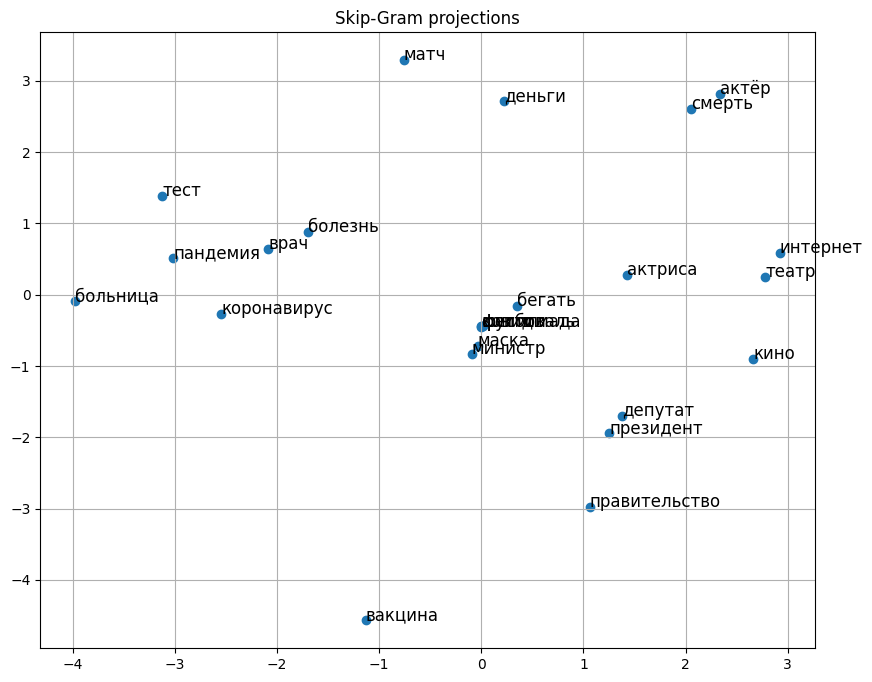

In [ ]:
words_to_plot = ['коронавирус', 'вакцина', 'пандемия', 'ковид', 'тест',
                  'футбол', 'хоккей', 'матч', 'олимпиада',
                  'президент', 'правительство', 'министр', 'депутат',
                  'театр', 'кино', 'фестиваль', 'актёр', 'актриса', 'врач',
                  'интернет', 'болезнь', 'смерть', 'больница', 'деньги',
                  'маска', 'бегать']

def plot_embeddings(embeddings_obj, words, title):
    vectors = []
    valid_words = []
    for w in words:
        if w in embeddings_obj.word2id:
            vectors.append(embeddings_obj.get_vector(w))
            valid_words.append(w)

    if len(vectors) < 2:
        print("Недостаточно слов для визуализации")
        return

    pca = PCA(n_components=2)
    vecs_2d = pca.fit_transform(np.array(vectors))

    plt.figure(figsize=(10, 8))
    plt.scatter(vecs_2d[:, 0], vecs_2d[:, 1])
    for i, word in enumerate(valid_words):
        plt.annotate(word, (vecs_2d[i, 0], vecs_2d[i, 1]), fontsize=12)
    plt.title(title)
    plt.grid(True)
    plt.show()

# print(f"{Fore.RED}Визуализация CBOW эмбеддингов:{Style.RESET_ALL}")
# plot_embeddings(cbow_emb, words_to_plot, "CBOW projections")

print(f"{Fore.RED}Визуализация Skip-Gram эмбеддингов:{Style.RESET_ALL}")
plot_embeddings(sg_emb, words_to_plot, "Skip-Gram projections")

В целом, можно увидеть некоторые более или менее верно очерченные кластеры:

**1** - тест, пандемия, врач, болезнь, коронавирус (но вакцина, при этом, находится далеко)

**2** - депутат, президент, правительство, министр

**3** - футбол, олимпиада, бегать (но здесь же маска и министр, а матч далеко)

**4** - интернет, театр, кино, актриса (при этом интернет ближе к театру, чем кино, и далеко находится актёр)

Слово "смерть", казалось бы, должно быть ближе к кластеру про коронавирус, но оно расположено рядом со словом "актёр". По визуализации не понятно, к каком кластеру относится слово "деньги".

Кластеризация неидеальная, но и не совсем плохая, тем более, если сравнивать с визуализацией CBOW (код закомментирован), на которой почти все слова лежат одной группой в центре графика и найти границы каких-либо кластеров почти невозможно. Во второй главе узнаем, можно ли улучшить результаты путем подбора других параметров.


### 7.2 Коллокаты и части речи

Используем нашу PoS-разметку, чтобы посмотреть, слова каких частей речи чаще всего являются ближайшими соседями для существительных и глаголов.

In [ ]:
# Функция для получения коллокатов
def get_collocates(embeddings_obj, word, tag_dict, k=10):
    similar = embeddings_obj.most_similar(word, k=k)
    result = []
    for sim_word, score in similar:
        pos = tag_dict.get(sim_word, ('UNK', None))[0]
        result.append((sim_word, pos, score))
    return result

# Пример для слова 'коронавирус' (существительное)
colls = get_collocates(sg_emb, 'коронавирус', train_tag_dict, k=15)
print(f"{Fore.RED}Коллокаты для 'коронавирус' (Skip-Gram):{Style.RESET_ALL}")
for word, pos, score in colls:
    print(f"{word} ({pos}) : {score:.4f}")

Коллокаты для 'коронавирус' (Skip-Gram):
удобна (UNK) : 0.4356
протестовать (UNK) : 0.4279
намного (UNK) : 0.3683
перенес (UNK) : 0.3614
катанию (UNK) : 0.3586
армянскую (UNK) : 0.3521
тренировка (UNK) : 0.3446
южноафриканский (UNK) : 0.3395
положительный (ADJ) : 0.3331
фигурному (UNK) : 0.3322
дмитрия (UNK) : 0.3268
запрещать (UNK) : 0.3231
образцах (UNK) : 0.3190
отрицательный (UNK) : 0.3189
монастырь (UNK) : 0.3151


#

# **Аналитическая часть: Эксперимент с гиперпараметрами**

In [ ]:
# Гиперпараметры Skip-Gram из предыдущей главы

# WINDOW_SIZE = 5
# NEG_SAMPLES = 10 # оставим 10 для второй главы
# EMB_DIM_SG = 300
# EPOCHS_SG = 10   # поменяем на 5 для всех моделей во второй главе

In [4]:
import time

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
torch.cuda.is_available()

True

In [ ]:
results = []

for window_s in [1, 3, 5]:
    for embedding_s in [50, 100, 200]:
        print(f"\n Загружаю Window={window_s}, Embedding size={embedding_s}")

        start_time = time.time()

        sg_dataset = SkipGramDataset(train_ids[:1000], window_s, NEG_SAMPLES, vocab_size)
        sg_model = SkipGramNegSampling(vocab_size, embedding_s)

        sg_model = train_skipgram(sg_model, sg_dataset, epochs=5, batch_size=512,
                                  device=device, max_batches=200)

        result_time = time.time() - start_time

        results.append({
            'window': window_s,
            'embedding': embedding_s,
            'model': sg_model,
            'time': result_time
        })

        torch.save(
            sg_model.state_dict(),
            f'/content/drive/MyDrive/sg_w{window_s}_em{embedding_s}.pt')

        with open('/content/drive/MyDrive/results.txt', 'a') as f:
            f.write(f"{window_s},{embedding_s},{result_time}\n")

for r in results:
    print(f"Модель с Window={r['window']}, Embedding size={r['embedding']} обучена за {r['time']:.1f} сек")


 Загружаю Window=1, Embedding size=50
Epoch 1, Loss: 0.9394
Epoch 2, Loss: 0.6087
Epoch 3, Loss: 0.4359
Epoch 4, Loss: 0.3231
Epoch 5, Loss: 0.2382

 Загружаю Window=1, Embedding size=100
Epoch 1, Loss: 0.9079
Epoch 2, Loss: 0.5648
Epoch 3, Loss: 0.3801
Epoch 4, Loss: 0.2657
Epoch 5, Loss: 0.1822

 Загружаю Window=1, Embedding size=200
Epoch 1, Loss: 0.8777
Epoch 2, Loss: 0.5328
Epoch 3, Loss: 0.3535
Epoch 4, Loss: 0.2371
Epoch 5, Loss: 0.1568

 Загружаю Window=3, Embedding size=50
Epoch 1, Loss: 0.9353
Epoch 2, Loss: 0.6751
Epoch 3, Loss: 0.5787
Epoch 4, Loss: 0.5096
Epoch 5, Loss: 0.4579

 Загружаю Window=3, Embedding size=100
Epoch 1, Loss: 0.9057
Epoch 2, Loss: 0.6486
Epoch 3, Loss: 0.5610
Epoch 4, Loss: 0.4845
Epoch 5, Loss: 0.4216

 Загружаю Window=3, Embedding size=200
Epoch 1, Loss: 0.8873
Epoch 2, Loss: 0.6550
Epoch 3, Loss: 0.5552
Epoch 4, Loss: 0.4756
Epoch 5, Loss: 0.4111

 Загружаю Window=5, Embedding size=50
Epoch 1, Loss: 0.9346
Epoch 2, Loss: 0.6767
Epoch 3, Loss: 0.60

In [18]:

checkpoint = torch.load('/content/drive/MyDrive/sg_w1_em50.pt')
print(f"Размер словаря из модели: {checkpoint['center_emb.weight'].shape[0]}")

Размер словаря из модели: 25677


In [19]:
vocab_size = 25677
models = {}

for window_s in [1, 3, 5]:
    for embedding_s in [50, 100, 200]:

        model = SkipGramNegSampling(vocab_size, embedding_s)
        model.load_state_dict(torch.load(f'/content/drive/MyDrive/sg_w{window_s}_em{embedding_s}.pt'))
        model.to(device)

        models[(window_s, embedding_s)] = model
        print(f"Загружена модель: Window={window_s}, Dim={embedding_s}")

Загружена модель: Window=1, Dim=50
Загружена модель: Window=1, Dim=100
Загружена модель: Window=1, Dim=200
Загружена модель: Window=3, Dim=50
Загружена модель: Window=3, Dim=100
Загружена модель: Window=3, Dim=200
Загружена модель: Window=5, Dim=50
Загружена модель: Window=5, Dim=100
Загружена модель: Window=5, Dim=200


In [38]:
def plot_embeddings(embeddings_obj, words, title):
    vectors = []
    valid_words = []
    for w in words:
        if w in embeddings_obj.word2id:
            vectors.append(embeddings_obj.get_vector(w))
            valid_words.append(w)

    if len(vectors) < 2:
        print("Недостаточно слов для визуализации")
        return

    pca = PCA(n_components=2)
    vecs_2d = pca.fit_transform(np.array(vectors))

    plt.figure(figsize=(10, 8))
    plt.scatter(vecs_2d[:, 0], vecs_2d[:, 1])
    for i, word in enumerate(valid_words):
        plt.annotate(word, (vecs_2d[i, 0], vecs_2d[i, 1]), fontsize=12)
    plt.title(title)
    plt.grid(True)
    plt.show()


Window=1, Dim=50


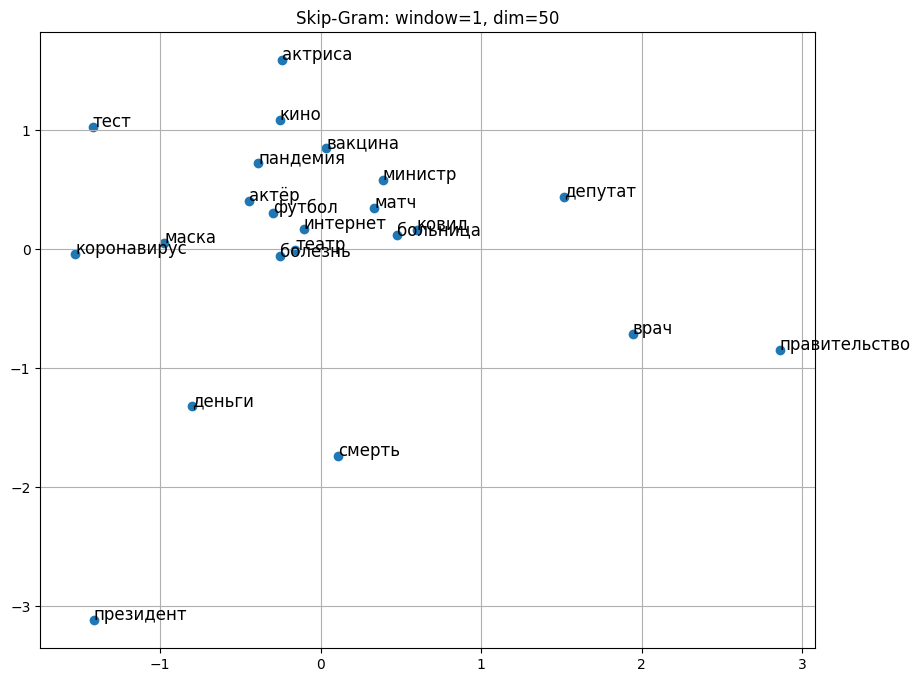


Window=1, Dim=100


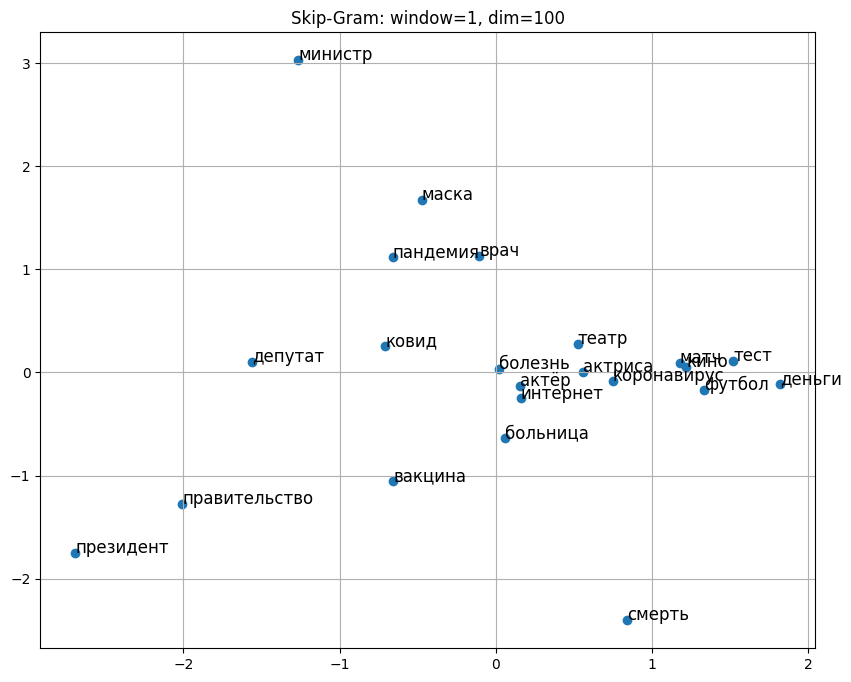


Window=1, Dim=200


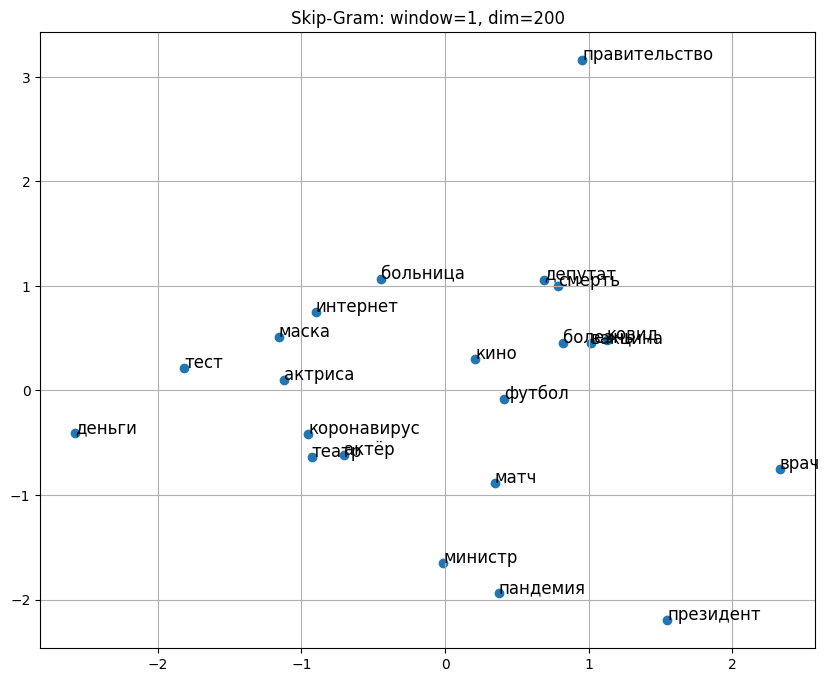


Window=3, Dim=50


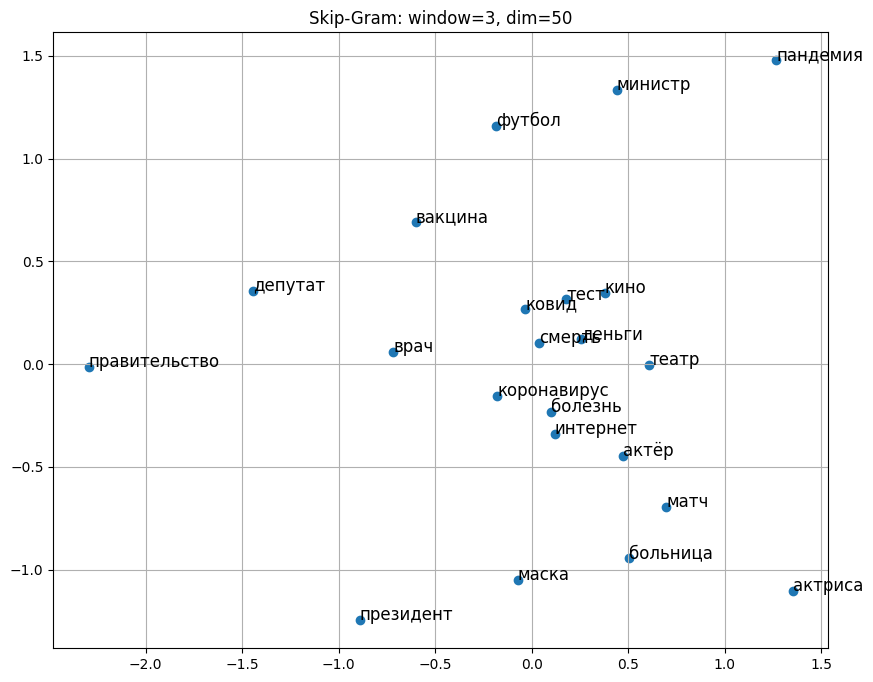


Window=3, Dim=100


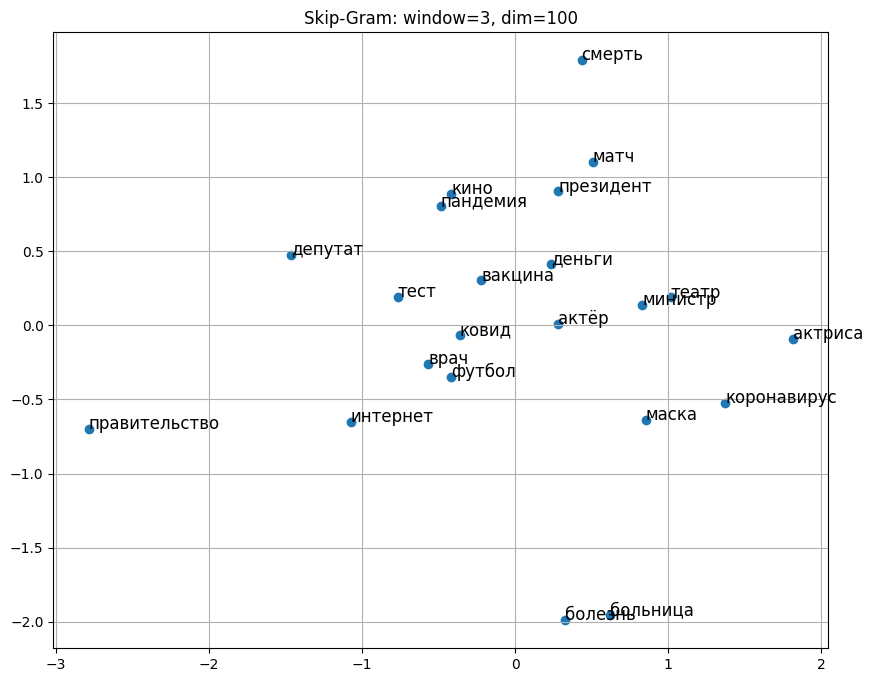


Window=3, Dim=200


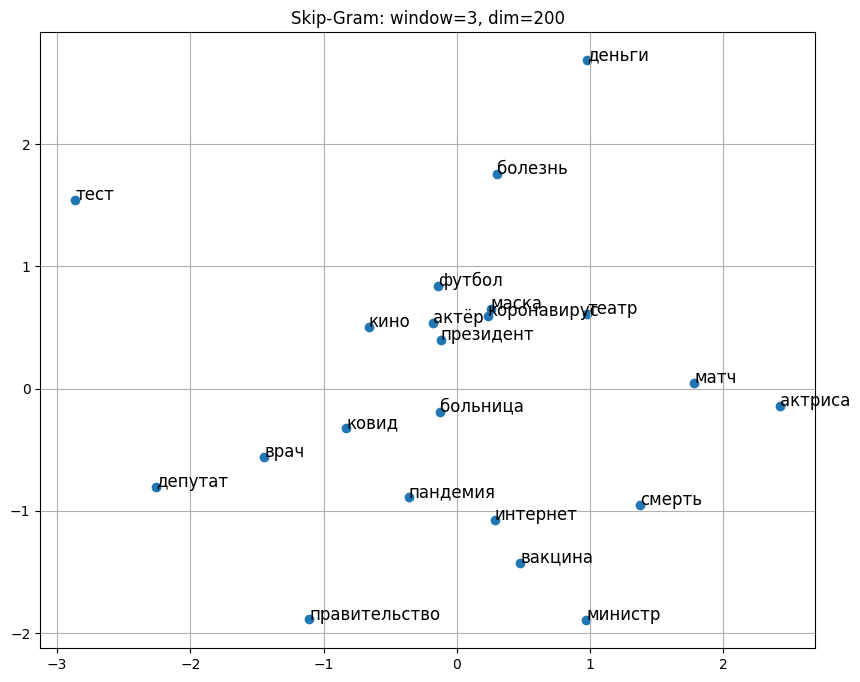


Window=5, Dim=50


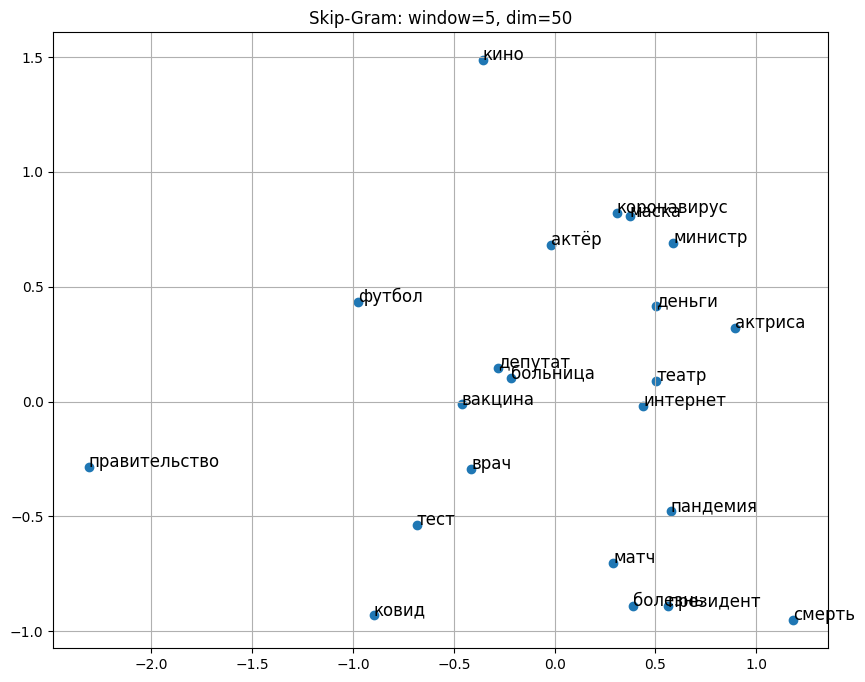


Window=5, Dim=100


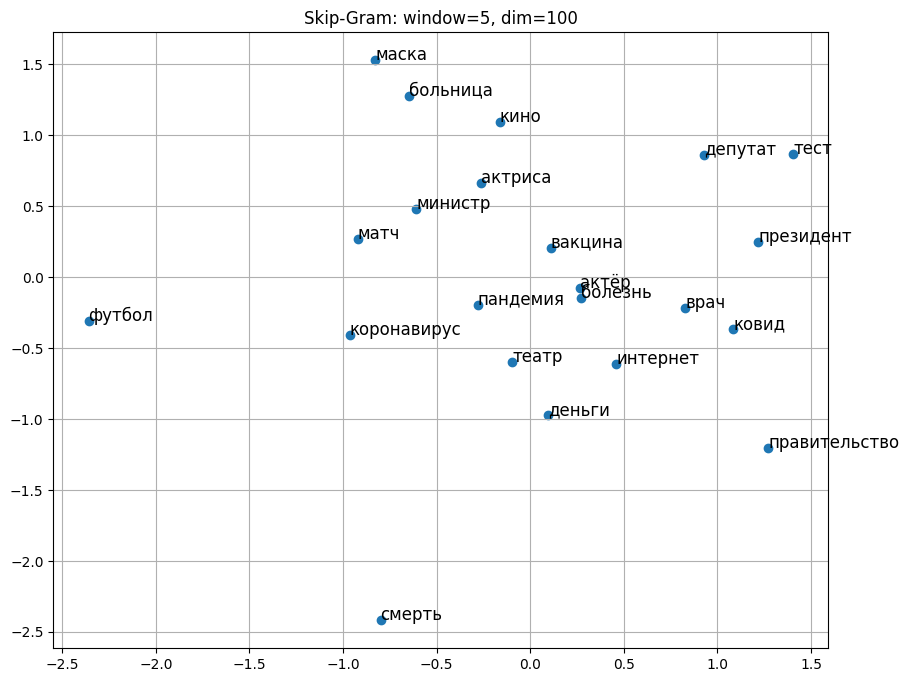


Window=5, Dim=200


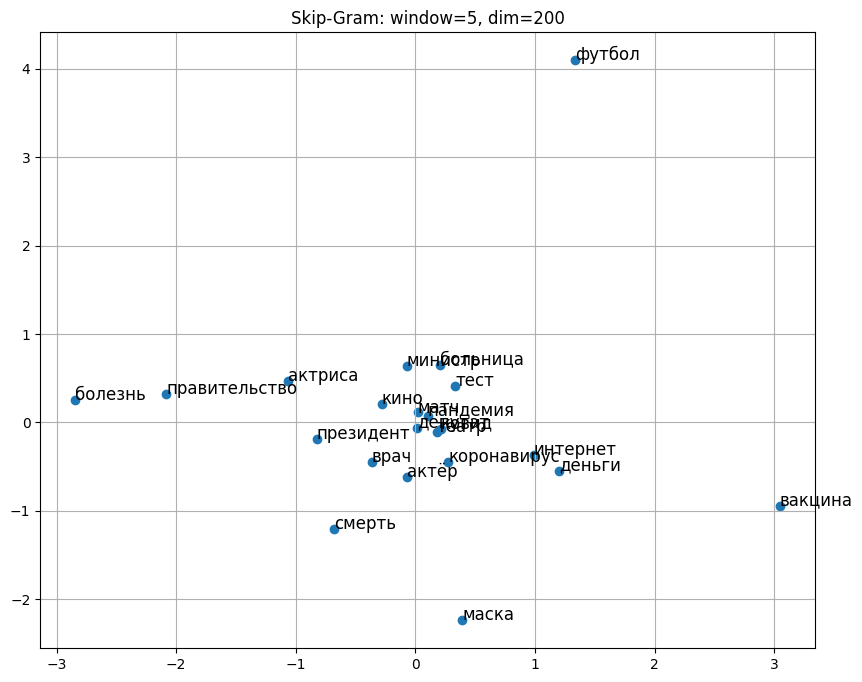

In [39]:
models_emb = {}
for window_s in [1, 3, 5]:
    for embedding_s in [50, 100, 200]:
        m = SkipGramNegSampling(vocab_size, embedding_s)
        m.load_state_dict(torch.load(f'/content/drive/MyDrive/sg_w{window_s}_em{embedding_s}.pt'))
        m.to(device)
        m.eval()

        models_emb[(window_s, embedding_s)] = WordEmbeddings(
            m.center_emb.weight.detach().cpu().numpy(),
            word2id
        )


words_to_plot = ['коронавирус', 'вакцина', 'пандемия', 'ковид', 'тест',
                  'футбол', 'матч',
                  'президент', 'правительство', 'министр', 'депутат',
                  'театр', 'кино', 'актёр', 'актриса', 'врач',
                  'интернет', 'болезнь', 'смерть', 'больница', 'деньги', 'маска']

for (window_s, embedding_s), emb_obj in models_emb.items():     # визуализации не очень, чётких кластеров нигде не видно
    print(f"\nWindow={window_s}, Dim={embedding_s}")
    plot_embeddings(emb_obj, words_to_plot, f"Skip-Gram: window={window_s}, dim={embedding_s}")

In [50]:
# косинусное сходство

print(f"{Fore.RED}Коллокаты для 'коронавирус' (Skip-Gram):{Style.RESET_ALL}")

for window_s in [1,3,5]:
    for embedding_s in [50,100,200]:
        emb = models_emb[(window_s, embedding_s)]

        colls = get_collocates(emb, 'коронавирус', train_tag_dict, k=5)

        print(f"\nWindow={window_s}, Dim={embedding_s}")
        for word, pos, score in colls:
            print(f"  {word} ({pos}) : {score:.4f}")

Коллокаты для 'коронавирус' (Skip-Gram):

Window=1, Dim=50
  запрет (NOUN) : 0.6890
  сумме (UNK) : 0.6476
  выплачивает (UNK) : 0.6394
  каждое (UNK) : 0.6213
  дипломы (UNK) : 0.6184

Window=1, Dim=100
  мерам (UNK) : 0.5454
  германией (UNK) : 0.5190
  рабочей (ADJ) : 0.5120
  трудится (UNK) : 0.4902
  заставило (UNK) : 0.4813

Window=1, Dim=200
  энергоснабжения (UNK) : 0.5372
  действиям (UNK) : 0.5243
  le (UNK) : 0.4547
  запретить (UNK) : 0.4486
  новокузнецке (UNK) : 0.4384

Window=3, Dim=50
  ввел (VERB) : 0.6291
  мерам (UNK) : 0.6012
  отходов (UNK) : 0.5928
  позднее (UNK) : 0.5675
  целей (UNK) : 0.5596

Window=3, Dim=100
  челябинской (UNK) : 0.4982
  потоки (UNK) : 0.4602
  подсудимых (UNK) : 0.4596
  ограничено (UNK) : 0.4506
  глаза (UNK) : 0.4467

Window=3, Dim=200
  формату (UNK) : 0.4136
  показывают (UNK) : 0.4133
  ввел (VERB) : 0.4115
  медика (UNK) : 0.4044
  кандидатов (UNK) : 0.4026

Window=5, Dim=50
  любили (VERB) : 0.7118
  вкладам (UNK) : 0.7049
  подключ

In [47]:
# аналогии "король - мужчина + женщина"

print(f"\n{Fore.RED}Аналогия 'король - мужчина + женщина' (Skip-Gram):{Style.RESET_ALL}")

for window_s in [1,3,5]:
    for embedding_s in [50,100,200]:
        emb = models_emb[(window_s, embedding_s)]

        # Пробуем найти королеву
        result = emb.analogy('король', 'мужчина', 'женщина', k=5)

        print(f"\nWindow={window_s}, Dim={embedding_s}")
        for word, score in result[:3]:
            print(f"  {word}: {score:.4f}")


Аналогия 'король - мужчина + женщина' (Skip-Gram):

Window=1, Dim=50
  увольнения: 0.5492
  артиллерийской: 0.5223
  отставного: 0.5148

Window=1, Dim=100
  fm: 0.3636
  молодую: 0.3623
  454: 0.3530

Window=1, Dim=200
  лекарство: 0.3307
  лещенко: 0.2573
  фортуна: 0.2545

Window=3, Dim=50
  явке: 0.5100
  находясь: 0.4966
  даются: 0.4603

Window=3, Dim=100
  участились: 0.4064
  высший: 0.3540
  посмотреть: 0.3444

Window=3, Dim=200
  сыграет: 0.2772
  этапом: 0.2662
  сознался: 0.2660

Window=5, Dim=50
  объединении: 0.5288
  ядерщика: 0.4916
  риа: 0.4782

Window=5, Dim=100
  используется: 0.4020
  разное: 0.3907
  опубликованы: 0.3823

Window=5, Dim=200
  олеся: 0.2887
  укладку: 0.2778
  джорджа: 0.2681


In [49]:
# аналогии "актёр - мужчина + женщина"

print(f"\n{Fore.RED}Аналогия 'актёр - мужчина + женщина' (Skip-Gram):{Style.RESET_ALL}")

for window_s in [1,3,5]:
    for embedding_s in [50,100,200]:
        emb = models_emb[(window_s, embedding_s)]

        # Пробуем найти королеву
        result = emb.analogy('актёр', 'мужчина', 'женщина', k=5)

        print(f"\nWindow={window_s}, Dim={embedding_s}")
        for word, score in result[:3]:
            print(f"  {word}: {score:.4f}")


Аналогия 'актёр - мужчина + женщина' (Skip-Gram):

Window=1, Dim=50
  артиллерийской: 0.6687
  увольнения: 0.5260
  вырастет: 0.4990

Window=1, Dim=100
  задача: 0.4427
  такую: 0.4411
  мнения: 0.4286

Window=1, Dim=200
  лекарство: 0.3100
  лещенко: 0.2981
  фортуна: 0.2778

Window=3, Dim=50
  форматах: 0.5952
  судна: 0.5812
  прописана: 0.5484

Window=3, Dim=100
  участились: 0.3845
  посмотреть: 0.3651
  байдена: 0.3620

Window=3, Dim=200
  евгений: 0.3290
  сознался: 0.3254
  his: 0.3253

Window=5, Dim=50
  садовом: 0.6012
  дана: 0.5952
  просьбу: 0.5918

Window=5, Dim=100
  говорит: 0.4813
  используется: 0.4739
  призвать: 0.4730

Window=5, Dim=200
  джорджа: 0.3648
  совершенное: 0.3576
  укладку: 0.3513


## Выводы

**Влияние размера окна**

 При маленьком окне (window=1) модель демонстрирует наилучшую сходимость: значение функции потерь снижается с увеличением размерности до 0.16. С увеличением окна до 3 и 5 итоговый loss после 5 эпох составляет 0.41 и 0.48 соотвественно, что почти в 2-3 раза хуже, чем при window=1. Однако качественных тематических связей не наблюдается ни при одном размере окна, что, возможно, связано с недостаточным количеством эпох обучения.

**Влияние размерности эмбеддинга**

Наблюдается четкая закономерность: большая размерность дает более низкий финальный loss. Например, при window=1 loss снижается с 0.24 (dim=50) до 0.16 (dim=200). Аналогичная тенденция сохраняется для window=3 (0.46 vs 0.41) и window=5 (0.50 vs 0.48). Однако при анализе аналогий "король — мужчина + женщина" и "актёр — мужчина + женщина" все модели выдают случайные лексемы.

**Скорость обучения**

Скорость обучения самой медленной модели = 994 сек, самой быстрой = 973 сек. Разница - 21 секунда, это около 2%. У самой быстрой модели - самое большое контекстное окно и маленькая размерность, у самой медленной - самое маленькое контекстное окно и средняя размерность. Можно сделать вывод о том, что эти параметры в данном случае не повлияли на скорость обучения. В первой главе у Skip-Gram'а было больше эпох - обучалась модель дольше. Также на скорость обучения влияет размер батча.

**Выводы**

Для поиска синтаксически близких слов больше подходит маленькое окно (window=1). Размерность эмбеддинга однозначно влияет на качество: чем выше размерность, тем лучше потенциальное качество, но при этом требуется больше данных и эпох для полноценного обучения. Сказать, какая модель лучше видит синтаксические связи, какая - тематические, достаточно сложно, т.к. ни те, ни другие виды связи в примерах, полученных в результате работы модели, не очевидны.



In [ ]:
# Модель с Window=1, Embedding size=50 обучена за 988.1 сек
# Модель с Window=1, Embedding size=100 обучена за 993.9 сек
# Модель с Window=1, Embedding size=200 обучена за 992.7 сек
# Модель с Window=3, Embedding size=50 обучена за 980.4 сек
# Модель с Window=3, Embedding size=100 обучена за 976.0 сек
# Модель с Window=3, Embedding size=200 обучена за 975.9 сек
# Модель с Window=5, Embedding size=50 обучена за 972.7 сек
# Модель с Window=5, Embedding size=100 обучена за 980.2 сек
# Модель с Window=5, Embedding size=200 обучена за 977.8 сек